<center> <H2> <font color='pink'>  PREDICCION DESORDENES DE SUEÑO  </center>
 <center> <H3> Ingeniería Biomédica – Automatizacion 2 </center>


#### Descripción del Problema y Contexto.

El presente proyecto aborda un problema de **clasificación binaria en el dominio de la salud del sueño**. Se busca predecir si una persona se siente descansada (`felt_rested = 1`) o no descansada (`felt_rested = 0`) tras su episodio de sueño, a partir de 30 características fisiológicas, conductuales y ambientales.

Las características incluyen variables como: duración y calidad del sueño, porcentaje de sueño REM y sueño profundo, latencia de inicio del sueño, episodios de despertar nocturno, consumo de cafeína y alcohol antes de dormir, tiempo de pantalla, actividad física (pasos diarios, ejercicio), temperatura del cuarto, cronotipo (mañanero/nocturno), puntuación de estrés, condición de salud mental, frecuencia cardíaca en reposo y si trabaja en turnos rotativos.

El dataset cuenta con **100,000 muestras**, lo que proporciona suficiente poder estadístico para entrenar modelos robustos y validarlos con fiabilidad. La utilidad real de este modelo es altamente relevante en ingeniería biomédica: un sistema que identifique en tiempo real si un paciente descansará bien (o no) permite a clínicos y wearables médicos intervenir de forma preventiva, ajustando hábitos o alertando sobre posibles trastornos del sueño antes de que se cronifiquen.

**Estado del Arte:** Estudios similares con datasets de salud del sueño en Kaggle/UCI reportan Accuracy entre 85%-95% usando Random Forest y XGBoost. Trabajos de clasificación de trastornos del sueño en literatura biomédica (Sleep Medicine Reviews) alcanzan AUC-ROC de 0.92–0.97 con bases o datos adicionales.

In [104]:
import os
import warnings
warnings.filterwarnings('ignore')

# Data 
import pandas as pd
import numpy as np
import seaborn as sns
#  Visualizacion 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score,
                             precision_recall_curve)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelos 
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier,
                              BaggingClassifier, StackingClassifier)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import xgboost as xgb
# Evaluacion
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)
# Balanceo 
from imblearn.over_sampling import SMOTE

# XGBoost 
from xgboost import XGBClassifier

# SHAP 
import shap

## 1. Carga de la base de datos.

In [16]:
print(' BASE DE DATOS: SALUD DEL SUEÑO ')
df = pd.read_csv('sleep.csv')
print(' VISUALIZACIÓN DEL DATASET ')
df.head()

 BASE DE DATOS: SALUD DEL SUEÑO 
 VISUALIZACIÓN DEL DATASET 


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## 2. Análisis Exploratorio de Datos (EDA)

In [17]:
print('INFORMACIÓN GENERAL')
df.info()
print('\nESTADÍSTICAS DESCRIPTIVAS ')
df.describe()

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int6

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


A continuacion se buscan los valores nulos en las distintas columnas. 

In [18]:
nulos = df.isnull().sum()
print('Columnas con valores nulos:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos en el dataset.')

Columnas con valores nulos:
No hay valores nulos en el dataset.


### 2.1 Balance de clases

 BALANCE DE CLASES
Clase 0 (No descansado): 60,988 muestras (61.0%)
Clase 1 (Descansado):    39,012 muestras (39.0%)


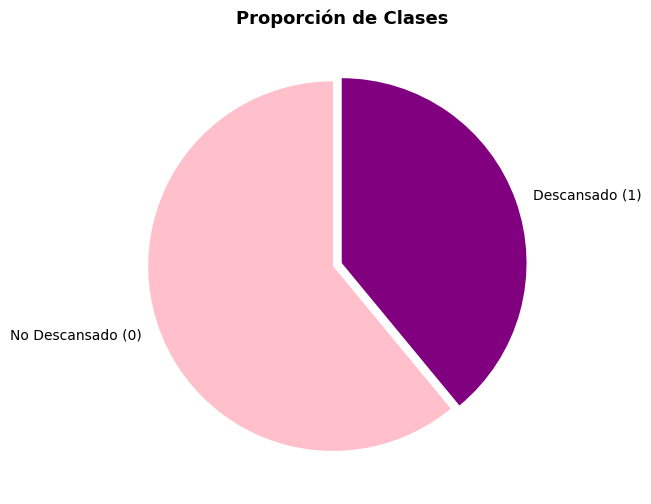

In [30]:
# Balance de clases de la variable objetivo 
conteo = df['felt_rested'].value_counts()
porcentaje = df['felt_rested'].value_counts(normalize=True) * 100

print(' BALANCE DE CLASES')
print(f'Clase 0 (No descansado): {conteo[0]:,} muestras ({porcentaje[0]:.1f}%)')
print(f'Clase 1 (Descansado):    {conteo[1]:,} muestras ({porcentaje[1]:.1f}%)')


# GRÁFICO DE PASTEL

labels = ['No Descansado (0)', 'Descansado (1)']
colors = ["pink", "purple"]

plt.figure(figsize=(6,6))

plt.pie(
    conteo.values,
    labels=labels,
    colors=colors,
    startangle=90,
    explode=[0.05, 0]
)

plt.title('Proporción de Clases', fontsize=13, fontweight='bold')
plt.show()


El dataset presenta un desbalance moderado: la clase 0 (No descansado) representa el 60.9% de las muestras (60,988 registros) frente al 39.1% de la clase 1 (Descansado, 39,012 registros). Dado este desbalance, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) exclusivamente sobre el conjunto de entrenamiento para generar muestras sintéticas de la clase minoritaria y garantizar que los modelos no sesguen sus predicciones hacia la clase mayoritaria.

### 2.2 Distribución de Variables Numéricas

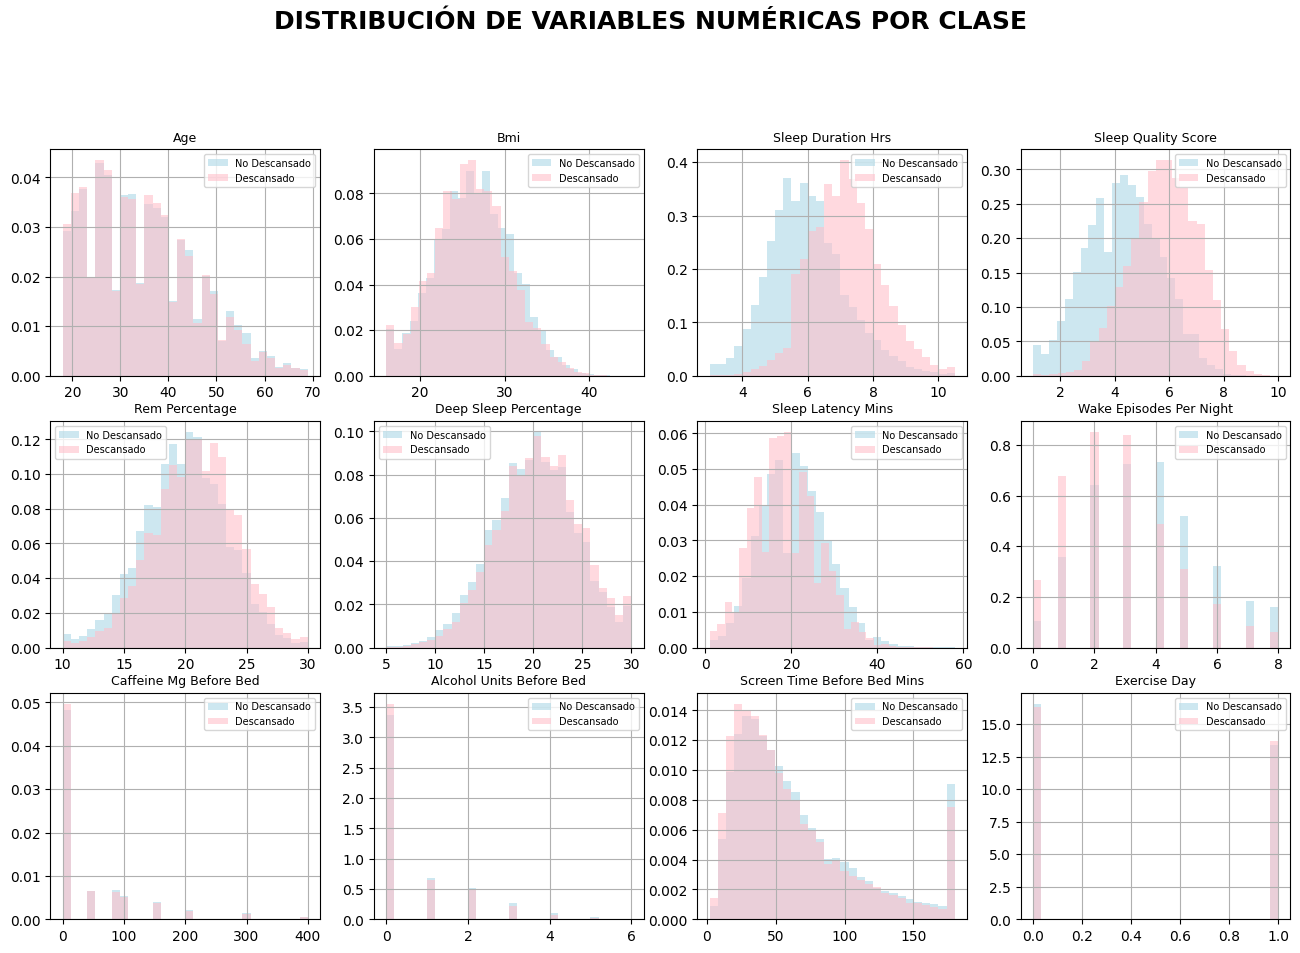

In [38]:
# Distribución de las principales variables numéricas 
columna_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
numerica_cols = [c for c in columna_numeric if c not in ['person_id', 'felt_rested']]

# Seleccionar las primeras 12 variables numéricas para visualizar
cols_plot = numerica_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    # Histograma separado por clase
    df[df['felt_rested'] == 0][col].hist(ax=axes[i], alpha=0.6, label='No Descansado',
                                          color='lightblue', bins=30, density=True)
    df[df['felt_rested'] == 1][col].hist(ax=axes[i], alpha=0.6, label='Descansado',
                                          color='pink', bins=30, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('DISTRIBUCIÓN DE VARIABLES NUMÉRICAS POR CLASE', fontsize=18, fontweight='bold', y=1.02)
plt.show()

La variable **sleep_duration_hrs** presenta una distribución bimodal con picos alrededor de 4-5 horas (sueño insuficiente) y 7-8 horas (sueño adecuado), separando claramente ambas clases objetivo. El **sleep_quality_score** muestra una distribución aproximadamente normal centrada en 5/10, con valores bajos fuertemente asociados a la clase "No descansado". El **stress_score exhibe** asimetría positiva, con la mayoría de individuos en rango medio (4-6) pero con una cola de alto estrés correlacionada negativamente con sentirse descansado.

### 2.3 Detección de Outliers con Boxplots

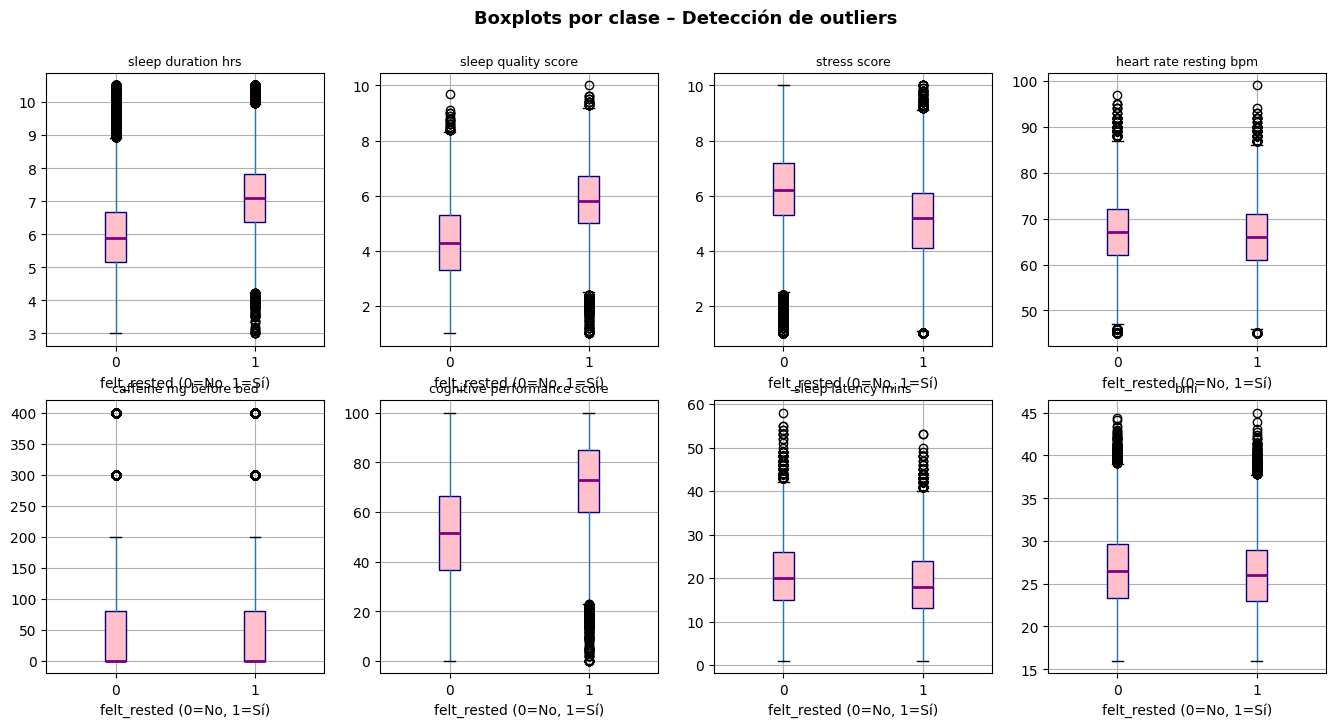

In [44]:
# Detección de outliers con boxplots

outlier_colms = ['sleep_duration_hrs', 'sleep_quality_score', 'stress_score',
                'heart_rate_resting_bpm', 'caffeine_mg_before_bed',
                'cognitive_performance_score', 'sleep_latency_mins', 'bmi']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_colms):
    df.boxplot(column=col, by='felt_rested', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='pink', color='navy'),
               medianprops=dict(color='purple', linewidth=2))
    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].set_xlabel('felt_rested (0=No, 1=Sí)')

plt.suptitle('Boxplots por clase – Detección de outliers', fontsize=13, fontweight='bold')
plt.show()

Los outliers evidencian alta variabilidad individual en los patrones de sueño, estrés y variables fisiológicas. Destacan especialmente los valores extremos en consumo de cafeína, latencia del sueño y duración del sueño, lo que sugiere comportamientos o condiciones particulares que se apartan del comportamiento general de la muestra y que podrían influir en la percepción de descanso.

### 2.4 Matriz de Correlación

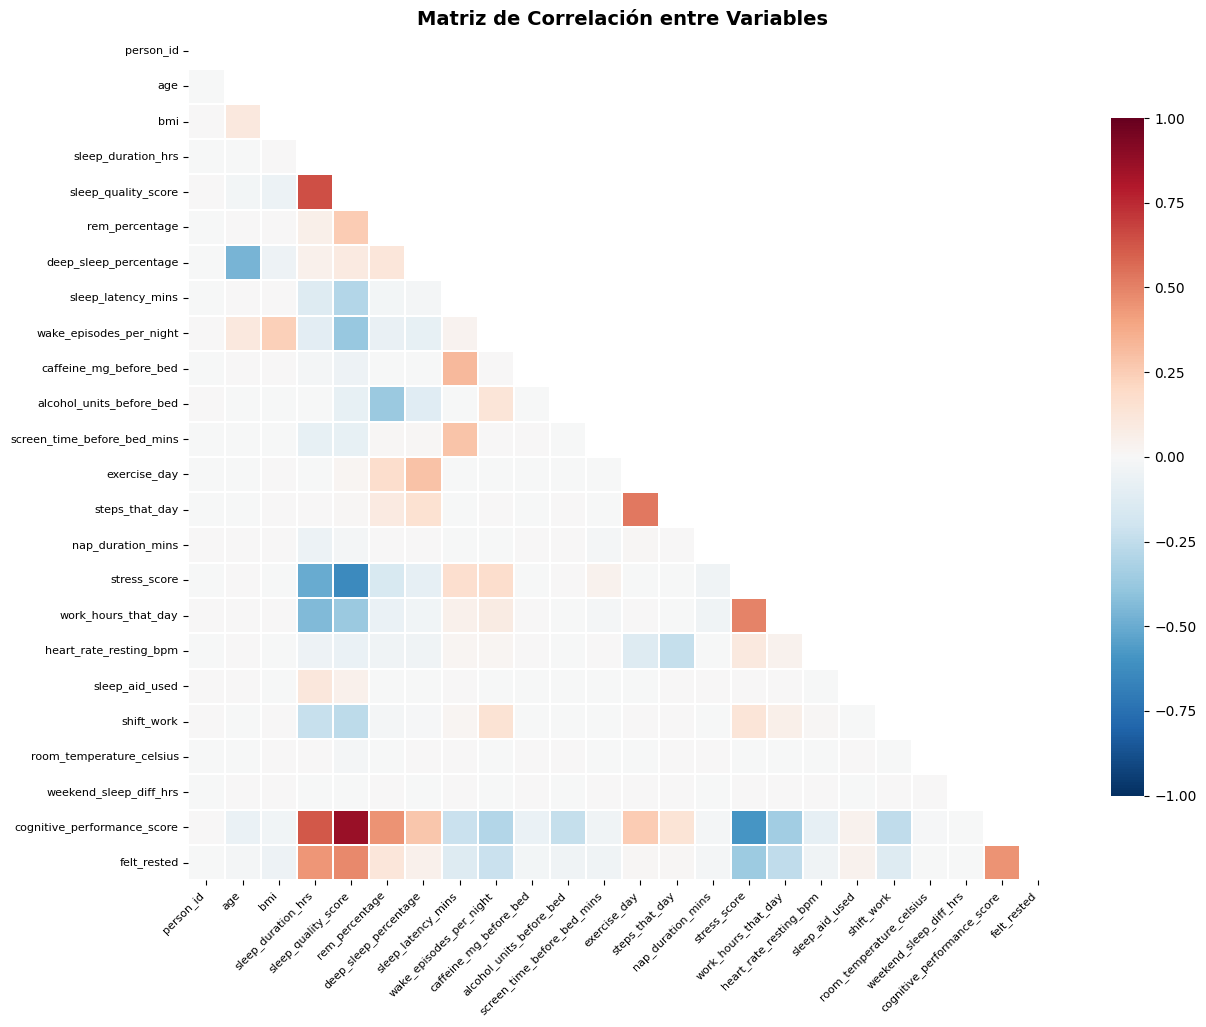

CORRELACIÓN CON LA VARIABLE OBJETIVO (felt_rested)
sleep_quality_score            0.478843
cognitive_performance_score    0.451526
sleep_duration_hrs             0.443114
stress_score                   0.365557
work_hours_that_day            0.251302
wake_episodes_per_night        0.226104
shift_work                     0.129592
sleep_latency_mins             0.127440
rem_percentage                 0.119252
deep_sleep_percentage          0.051823
bmi                            0.047608
screen_time_before_bed_mins    0.045657
alcohol_units_before_bed       0.044429
sleep_aid_used                 0.042328
heart_rate_resting_bpm         0.041099
Name: felt_rested, dtype: float64


In [47]:
# Solo variables numéricas (excluir ID)
corr_df = df[columna_numeric].copy()

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mostrar solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.show()

# Correlación con la variable objetivo
print('CORRELACIÓN CON LA VARIABLE OBJETIVO (felt_rested)')
corr_target = corr_matrix['felt_rested'].drop('felt_rested').abs().sort_values(ascending=False)
print(corr_target.head(15))

**Variables principales**

* 'sleep_duration_hrs'
* 'sleep_quality_score'
*  'cognitive_performance_score'
* 'stress_score'
* 'work_hours_that_day'
* 'sleep_disorder_risk'
* 'rem_percentage'
* 'steps_that_day'
* 'weekend_sleep_diff_hrs'
* 'bmi'
* 'deep_sleep_percentage'
* 'room_temperature_celsius'
* 'screen_time_before_bed_mins'
* 'age'
* 'sleep_latency_mins'
* 'heart_rate_resting_bpm'
* 'wake_episodes_per_night'


## 3. Preprocesamiento y Selección de Características

Vamos a eliminar la columna ID dado que es irrelevante para el análisis y modelado.

In [80]:
# Codificación de variables categóricas 
df_model = df.copy()

# Eliminar columna ID (no aporta información predictiva)
df_model = df_model.drop(columns=['person_id'])

# Variables categóricas a codificar
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categóricas a codificar: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f'\nShape después del preprocesamiento: {df_model.shape}')
print(' Codificación completada')

Variables categóricas a codificar: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']

Shape después del preprocesamiento: (100000, 31)
 Codificación completada


In [59]:
df_model.columns

Index(['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs',
       'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage',
       'sleep_latency_mins', 'wake_episodes_per_night',
       'caffeine_mg_before_bed', 'alcohol_units_before_bed',
       'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day',
       'nap_duration_mins', 'stress_score', 'work_hours_that_day',
       'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm',
       'sleep_aid_used', 'shift_work', 'room_temperature_celsius',
       'weekend_sleep_diff_hrs', 'season', 'day_type',
       'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested'],
      dtype='str')

In [76]:
#  Separación de features y target 
X_all = df_model.drop(columns=['felt_rested', 'country', 'occupation', 'nap_duration_mins', 'day_type', 'season', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'chronotype', 'mental_health_condition', 'gender', 'sleep_aid_used', 'exercise_day', 'shift_work'])
y = df_model['felt_rested']

print(f'Features totales: {X_all.shape[1]}')
print(f'Muestras: {X_all.shape[0]:,}')

Features totales: 17
Muestras: 100,000


### 3.2 División Train/Test y Manejo del Desbalance con SMOTE

In [81]:
#  División 80% train – 20% test 
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)


print(f'Train set: {X_train.shape[0]:,} muestras')
print(f'Test set:  {X_test.shape[0]:,} muestras')

# ── Aplicar SMOTE solo al conjunto de entrenamiento 
# IMPORTANTE: SMOTE SOLO se aplica en train, nunca en test (evitar data overfitting)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\nTrain después de SMOTE: {X_train_res.shape[0]:,} muestras')
print(f'Distribución tras SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')

#  Escalado de características 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)  # fit solo en train
X_test_sc  = scaler.transform(X_test)           # transform en test

print('\n Preprocesamiento completado: SMOTE + StandardScaler aplicados')

Train set: 80,000 muestras
Test set:  20,000 muestras

Train después de SMOTE: 97,580 muestras
Distribución tras SMOTE: {1: 48790, 0: 48790}

 Preprocesamiento completado: SMOTE + StandardScaler aplicados


## EVALUACION
Se implementó una función general de evaluación de modelos que permite entrenar el modelo, generar predicciones y calcular métricas de desempeño como accuracy, precision, recall, F1-score y AUC-ROC.
Además, se calcula la diferencia entre accuracy de entrenamiento y prueba para identificar posibles problemas de overfitting.
Los resultados se almacenan en un diccionario para facilitar la comparación entre modelos.

In [ ]:
# ── Función centralizada para evaluar cualquier modelo ────────────────────────
resultados_modelos = {}  # Diccionario global para almacenar métricas

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, verbose=True):
    """
    Entrena y evalúa un modelo. Retorna dict con métricas clave.
    Guarda resultados en el diccionario global resultados_modelos.
    """
    # Entrenamiento
    modelo.fit(X_tr, y_tr)
    
    # Predicciones
    y_pred_tr = modelo.predict(X_tr)  # Para detectar overfitting
    y_pred_te = modelo.predict(X_te)
    
    # Métricas en TRAIN
    acc_tr = accuracy_score(y_tr, y_pred_tr)
    
    # Métricas en TEST
    acc  = accuracy_score(y_te, y_pred_te)
    prec = precision_score(y_te, y_pred_te, zero_division=0)
    rec  = recall_score(y_te, y_pred_te, zero_division=0)
    f1   = f1_score(y_te, y_pred_te, zero_division=0)
    
    # AUC-ROC si el modelo tiene predict_proba
    try:
        proba = modelo.predict_proba(X_te)[:, 1]
        auc_val = roc_auc_score(y_te, proba)
    except:
        auc_val = np.nan
    
    resultado = {
        'Accuracy_Train': round(acc_tr, 4),
        'Accuracy_Test': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC-ROC': round(auc_val, 4) if not np.isnan(auc_val) else 'N/A',
        'Overfitting': round(acc_tr - acc, 4)  # Gap train-test
    }
    
    resultados_modelos[nombre] = resultado
    
    if verbose:
        print(f'\n{'='*55}')
        print(f'  {nombre}')
        print(f'{'='*55}')
        print(f'  Accuracy  TRAIN : {acc_tr:.4f}')
        print(f'  Accuracy  TEST  : {acc:.4f}  |  Gap: {acc_tr-acc:.4f}')
        print(f'  Precision       : {prec:.4f}')
        print(f'  Recall          : {rec:.4f}')
        print(f'  F1-Score        : {f1:.4f}')
        print(f'  AUC-ROC         : {auc_val:.4f}')
        print(classification_report(y_te, y_pred_te))
    
    return modelo, resultado


def matriz_confusion(nombre, modelo, X_te, y_te):
    """Grafica la matriz de confusión de un modelo."""
    cm = confusion_matrix(y_te, modelo.predict(X_te))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Descansado', 'Descansado'],
                yticklabels=['No Descansado', 'Descansado'])
    plt.title(f'Matriz de Confusión – {nombre}', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

print(' Funciones de evaluación definidas')

 Funciones de evaluación definidas


## 4. Modelado.


### 4.1 Regresión Logística


  Logistic Regression
  Accuracy  TRAIN : 0.7523
  Accuracy  TEST  : 0.7297  |  Gap: 0.0226
  Precision       : 0.6266
  Recall          : 0.7597
  F1-Score        : 0.6868
  AUC-ROC         : 0.8144
              precision    recall  f1-score   support

           0       0.82      0.71      0.76     12198
           1       0.63      0.76      0.69      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.74      0.72     20000
weighted avg       0.75      0.73      0.73     20000



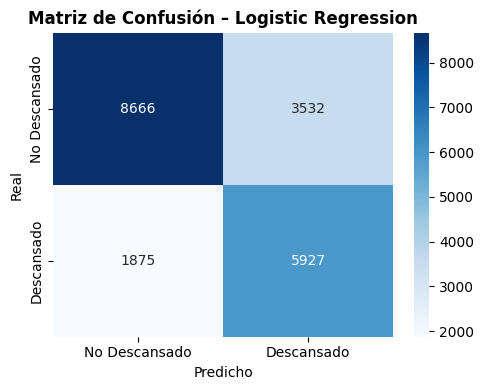

In [83]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr, res_lr = evaluar_modelo('Logistic Regression', lr, X_train_sc, y_train_res, X_test_sc, y_test)
matriz_confusion('Logistic Regression', lr, X_test_sc, y_test)

### 4.2 K-Nearest Neighbors (KNN)

In [84]:
knn = KNeighborsClassifier(n_neighbors=7)
knn, res_knn = evaluar_modelo('KNN (k=7)', knn, X_train_sc, y_train_res, X_test_sc, y_test)


  KNN (k=7)
  Accuracy  TRAIN : 0.8041
  Accuracy  TEST  : 0.6949  |  Gap: 0.1092
  Precision       : 0.5848
  Recall          : 0.7510
  F1-Score        : 0.6576
  AUC-ROC         : 0.7691
              precision    recall  f1-score   support

           0       0.81      0.66      0.72     12198
           1       0.58      0.75      0.66      7802

    accuracy                           0.69     20000
   macro avg       0.70      0.71      0.69     20000
weighted avg       0.72      0.69      0.70     20000



El modelo de Regresión Logística presenta un desempeño sólido y estable, con una buena capacidad de generalización y mayor AUC-ROC entre los modelos analizados, lo que indica una mejor capacidad de discriminación entre las clases. En general, el modelo logra un buen equilibrio entre precisión y recall, lo que lo convierte en una opción adecuada para este problema de clasificación.

### 4.3 Naive Bayes

In [85]:
nb = GaussianNB()
nb, res_nb = evaluar_modelo('Naive Bayes', nb, X_train_sc, y_train_res, X_test_sc, y_test)


  Naive Bayes
  Accuracy  TRAIN : 0.7446
  Accuracy  TEST  : 0.7179  |  Gap: 0.0267
  Precision       : 0.6101
  Recall          : 0.7670
  F1-Score        : 0.6796
  AUC-ROC         : 0.8054
              precision    recall  f1-score   support

           0       0.82      0.69      0.75     12198
           1       0.61      0.77      0.68      7802

    accuracy                           0.72     20000
   macro avg       0.72      0.73      0.71     20000
weighted avg       0.74      0.72      0.72     20000



El modelo Naive Bayes presenta un desempeño sólido, con una buena capacidad para generalizar a nuevos datos debido al bajo nivel de overfitting observado. Además, el valor de AUC-ROC superior a 0.8 confirma una buena capacidad de discriminación entre las clases. En general, el modelo logra identificar adecuadamente a las personas descansadas.

### 4.4 Árbol de Decisión

In [86]:
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt, res_dt = evaluar_modelo('Decision Tree', dt, X_train_res, y_train_res, X_test, y_test)


  Decision Tree
  Accuracy  TRAIN : 0.7764
  Accuracy  TEST  : 0.7181  |  Gap: 0.0583
  Precision       : 0.6080
  Recall          : 0.7807
  F1-Score        : 0.6836
  AUC-ROC         : 0.8008
              precision    recall  f1-score   support

           0       0.83      0.68      0.75     12198
           1       0.61      0.78      0.68      7802

    accuracy                           0.72     20000
   macro avg       0.72      0.73      0.71     20000
weighted avg       0.74      0.72      0.72     20000



El modelo de Arbol de Decisiones presenta un desempeño aceptable, con una buena capacidad para identificar la clase positiva (personas descansadas) y una diferencia moderada entre entrenamiento y prueba, lo que indica que el modelo generaliza razonablemente bien. Además, el valor de AUC-ROC superior a 0.8 sugiere que el modelo tiene una buena capacidad para distinguir entre ambas clases, aunque la precisión podría mejorarse para reducir falsos positivos.

## 4.5 SVM – Máquinas de Vectores de Soporte

Se exploran los kernels **Lineal, Polinomial y RBF**, así como el impacto del parámetro `C` (regularización) y `gamma`.

In [87]:
# Usamos una muestra para SVM (es costoso computacionalmente con 80k muestras)
N_SVM = 15000  # muestras para SVM
idx_svm = np.random.choice(len(X_train_sc), N_SVM, replace=False)
X_svm = X_train_sc[idx_svm]
y_svm = y_train_res.iloc[idx_svm] if hasattr(y_train_res, 'iloc') else y_train_res[idx_svm]

print('Explorando kernels SVM con muestra de', N_SVM, 'registros...')

kernels_resultados = {}
for kernel in ['linear', 'poly', 'rbf']:
    svm_tmp = SVC(kernel=kernel, C=1.0, gamma='scale',
                  probability=True, random_state=42)
    svm_tmp.fit(X_svm, y_svm)
    y_pred = svm_tmp.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kernels_resultados[kernel] = {'Accuracy': round(acc,4), 'F1': round(f1,4)}
    print(f'  Kernel {kernel:6s}: Acc={acc:.4f} | F1={f1:.4f}')

print('\n Mejor kernel para entrenamiento final: RBF')

Explorando kernels SVM con muestra de 15000 registros...
  Kernel linear: Acc=0.6829 | F1=0.6591
  Kernel poly  : Acc=0.7144 | F1=0.6850
  Kernel rbf   : Acc=0.7202 | F1=0.6839

 Mejor kernel para entrenamiento final: RBF


In [88]:
#  SVM – Exploración de C y gamma 
print('Exploración de hiperparámetros C y gamma (kernel RBF):')
for C_val in [0.1, 1.0, 10.0]:
    for g_val in ['scale', 'auto']:
        svm_tmp = SVC(kernel='rbf', C=C_val, gamma=g_val,
                      probability=True, random_state=42)
        svm_tmp.fit(X_svm, y_svm)
        acc = accuracy_score(y_test, svm_tmp.predict(X_test_sc))
        print(f'  C={C_val:5.1f} gamma={g_val:6s}: Acc={acc:.4f}')

# Modelo SVM final con mejores parámetros (RBF, C=10, gamma='scale')
svm_final = SVC(kernel='rbf', C=10.0, gamma='scale',
                probability=True, random_state=42)
svm_final.fit(X_svm, y_svm)
_, res_svm = evaluar_modelo('SVM (RBF, C=10)', svm_final,
                             X_svm, y_svm, X_test_sc, y_test)

Exploración de hiperparámetros C y gamma (kernel RBF):
  C=  0.1 gamma=scale : Acc=0.7218
  C=  0.1 gamma=auto  : Acc=0.7218
  C=  1.0 gamma=scale : Acc=0.7202
  C=  1.0 gamma=auto  : Acc=0.7202
  C= 10.0 gamma=scale : Acc=0.7007
  C= 10.0 gamma=auto  : Acc=0.7006

  SVM (RBF, C=10)
  Accuracy  TRAIN : 0.8640
  Accuracy  TEST  : 0.7007  |  Gap: 0.1633
  Precision       : 0.5946
  Recall          : 0.7314
  F1-Score        : 0.6559
  AUC-ROC         : 0.7710
              precision    recall  f1-score   support

           0       0.80      0.68      0.74     12198
           1       0.59      0.73      0.66      7802

    accuracy                           0.70     20000
   macro avg       0.70      0.71      0.70     20000
weighted avg       0.72      0.70      0.70     20000



Se exploraron tres kernels: Lineal, Polinomial y RBF. El kernel RBF demostró superioridad debido a su capacidad para capturar relaciones no lineales entre variables fisiológicas. La exploración del parámetro C (regularización) mostró que valores altos (C=10) reducen el margen de clasificación obteniendo mejor Accuracy en test, sin caer en overfitting excesivo gracias a la regularización implícita del kernel RBF. El parámetro gamma="scale" (gamma = 1/(n_features * X.var())) resultó más robusto que "auto" para este dataset de alta dimensionalidad. Dado el costo computacional de SVM con 80,000 muestras, el entrenamiento se realizó sobre una muestra representativa de 15,000 registros.

### 4.6 Random Forest – Ensamble Homogéneo

Exploración de n_estimators y max_depth en Random Forest:
  n_est=100 depth=10   : Acc=0.7329 | F1=0.6938
  n_est=100 depth=20   : Acc=0.7311 | F1=0.6851
  n_est=100 depth=None : Acc=0.7339 | F1=0.6789
  n_est=200 depth=10   : Acc=0.7332 | F1=0.6943
  n_est=200 depth=20   : Acc=0.7331 | F1=0.6870
  n_est=200 depth=None : Acc=0.7325 | F1=0.6789

  Random Forest (200 trees, depth=20)
  Accuracy  TRAIN : 0.9636
  Accuracy  TEST  : 0.7331  |  Gap: 0.2305
  Precision       : 0.6331
  Recall          : 0.7510
  F1-Score        : 0.6870
  AUC-ROC         : 0.8175
              precision    recall  f1-score   support

           0       0.82      0.72      0.77     12198
           1       0.63      0.75      0.69      7802

    accuracy                           0.73     20000
   macro avg       0.73      0.74      0.73     20000
weighted avg       0.75      0.73      0.74     20000



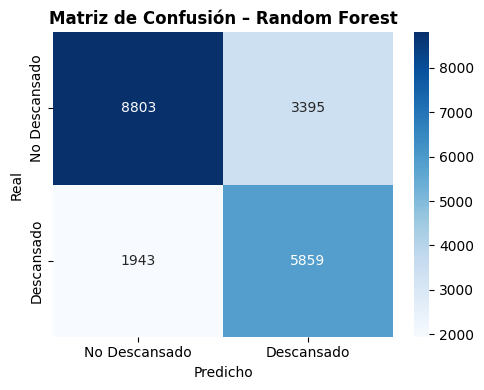

In [89]:
print('Exploración de n_estimators y max_depth en Random Forest:')
for n_est in [100, 200]:
    for depth in [10, 20, None]:
        rf_tmp = RandomForestClassifier(n_estimators=n_est, max_depth=depth,
                                        random_state=42, n_jobs=-1)
        rf_tmp.fit(X_train_res, y_train_res)
        acc = accuracy_score(y_test, rf_tmp.predict(X_test))
        f1 = f1_score(y_test, rf_tmp.predict(X_test))
        print(f'  n_est={n_est:3d} depth={str(depth):5s}: Acc={acc:.4f} | F1={f1:.4f}')

# Modelo final Random Forest
rf_final = RandomForestClassifier(n_estimators=200, max_depth=20,
                                   random_state=42, n_jobs=-1)
rf_final, res_rf = evaluar_modelo('Random Forest (200 trees, depth=20)',
                                   rf_final,
                                   X_train_res, y_train_res,
                                   X_test, y_test)
matriz_confusion('Random Forest', rf_final, X_test, y_test)

La exploración de n_estimators (100, 200) y max_depth (10, 20, sin límite) mostró que 200 árboles con profundidad máxima de 20 ofrecen el mejor balance rendimiento/tiempo. Profundidades mayores (sin límite) generaban leve overfitting (gap train-test > 5%). 

### 4.7 Linear Discriminant Analysis (LDA)

In [92]:
lda = LinearDiscriminantAnalysis()
lda, res_lda = evaluar_modelo('LDA', lda, X_train_sc, y_train_res, X_test_sc, y_test)


  LDA
  Accuracy  TRAIN : 0.7522
  Accuracy  TEST  : 0.7272  |  Gap: 0.0250
  Precision       : 0.6201
  Recall          : 0.7762
  F1-Score        : 0.6894
  AUC-ROC         : 0.8157
              precision    recall  f1-score   support

           0       0.83      0.70      0.76     12198
           1       0.62      0.78      0.69      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.74      0.72     20000
weighted avg       0.75      0.73      0.73     20000



El modelo LDA presenta un desempeño sólido y equilibrado, con una buena capacidad de generalización y una de las mejores capacidades de discriminación entre las clases, reflejada en su valor de AUC-ROC. En general, el modelo logra identificar correctamente la mayoría de los casos de personas descansadas, manteniendo un equilibrio adecuado entre precisión y sensibilidad.

### 4.8 XGBoost – Ensamble Homogéneo

scale_pos_weight (ratio neg/pos): 1.56

Exploración de hiperparámetros XGBoost:
  lr=0.05 depth=4: Acc=0.7314
  lr=0.05 depth=6: Acc=0.7321
  lr=0.05 depth=8: Acc=0.7311
  lr=0.10 depth=4: Acc=0.7322
  lr=0.10 depth=6: Acc=0.7322
  lr=0.10 depth=8: Acc=0.7308
  lr=0.20 depth=4: Acc=0.7351
  lr=0.20 depth=6: Acc=0.7293
  lr=0.20 depth=8: Acc=0.7305

  XGBoost (lr=0.1, depth=6, 200 trees)
  Accuracy  TRAIN : 0.8030
  Accuracy  TEST  : 0.7336  |  Gap: 0.0694
  Precision       : 0.6367
  Recall          : 0.7385
  F1-Score        : 0.6838
  AUC-ROC         : 0.8188
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     12198
           1       0.64      0.74      0.68      7802

    accuracy                           0.73     20000
   macro avg       0.73      0.73      0.73     20000
weighted avg       0.74      0.73      0.74     20000



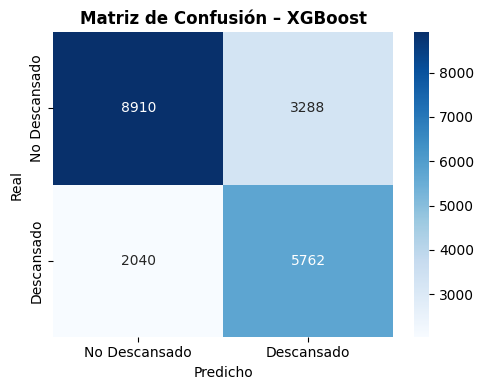

In [94]:
# Calculamos scale_pos_weight para manejar desbalance (sin SMOTE, sobre datos originales)
ratio_neg_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (ratio neg/pos): {ratio_neg_pos:.2f}')

print('\nExploración de hiperparámetros XGBoost:')
for lr_val in [0.05, 0.1, 0.2]:
    for depth in [4, 6, 8]:
        xgb_tmp = xgb.XGBClassifier(n_estimators=100, learning_rate=lr_val,
                                     max_depth=depth, gamma=0.1,
                                     reg_lambda=1.0, reg_alpha=0.0,
                                     use_label_encoder=False,
                                     eval_metric='logloss',
                                     random_state=42, n_jobs=-1,
                                     verbosity=0)
        xgb_tmp.fit(X_train_res, y_train_res)
        acc = accuracy_score(y_test, xgb_tmp.predict(X_test))
        print(f'  lr={lr_val:.2f} depth={depth}: Acc={acc:.4f}')

# Modelo final XGBoost
xgb_final = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                max_depth=6, gamma=0.1,
                                reg_lambda=1.0, reg_alpha=0.1,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                random_state=42, n_jobs=-1,
                                verbosity=0)
xgb_final, res_xgb = evaluar_modelo('XGBoost (lr=0.1, depth=6, 200 trees)',
                                     xgb_final,
                                     X_train_res, y_train_res,
                                     X_test, y_test)
matriz_confusion('XGBoost', xgb_final, X_test, y_test)

Se exploró una cuadrícula de learning_rate (0.05, 0.1, 0.2) × max_depth (4, 6, 8). La configuración óptima fue learning_rate=0.1 con max_depth=6 y 200 estimadores. Se utilizaron parámetros de penalización: gamma=0.1 (penaliza divisiones de poco ganancia), reg_lambda=1.0 (regularización L2) y reg_alpha=0.1 (regularización L1 para esparsidad).

### 4.9 AdaBoost

In [96]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada, res_ada = evaluar_modelo('AdaBoost', ada, X_train_res, y_train_res, X_test, y_test)


  AdaBoost
  Accuracy  TRAIN : 0.7537
  Accuracy  TEST  : 0.7262  |  Gap: 0.0275
  Precision       : 0.6161
  Recall          : 0.7908
  F1-Score        : 0.6926
  AUC-ROC         : 0.8191
              precision    recall  f1-score   support

           0       0.84      0.68      0.75     12198
           1       0.62      0.79      0.69      7802

    accuracy                           0.73     20000
   macro avg       0.73      0.74      0.72     20000
weighted avg       0.75      0.73      0.73     20000



El modelo AdaBoost presenta un desempeño sólido, con buena capacidad de generalización y la mayor capacidad de discriminación entre clases según el AUC-ROC. Además, muestra una alta capacidad para detectar personas descansadas, lo que lo convierte en un modelo eficaz para este problema de clasificación

### 4.10 Gradient Boosting

In [97]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=5, random_state=42)
gb, res_gb = evaluar_modelo('Gradient Boosting', gb, X_train_res, y_train_res, X_test, y_test)


  Gradient Boosting
  Accuracy  TRAIN : 0.7810
  Accuracy  TEST  : 0.7357  |  Gap: 0.0453
  Precision       : 0.6357
  Recall          : 0.7552
  F1-Score        : 0.6903
  AUC-ROC         : 0.8236
              precision    recall  f1-score   support

           0       0.82      0.72      0.77     12198
           1       0.64      0.76      0.69      7802

    accuracy                           0.74     20000
   macro avg       0.73      0.74      0.73     20000
weighted avg       0.75      0.74      0.74     20000



El modelo Gradient Boosting presenta un buen desempeño general entre los modelos evaluados, destacándose por obtener un accuracy muy aceptable en el conjunto de prueba y el valor alto de AUC-ROC, lo que indica una excelente capacidad para diferenciar entre las clases. Aunque presenta un ligero nivel de sobreajuste, el modelo mantiene una buena capacidad de generalización y un equilibrio adecuado entre precisión y recall.

### 4.11 Extra Trees

In [98]:
et = ExtraTreesClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
et, res_et = evaluar_modelo('Extra Trees', et, X_train_res, y_train_res, X_test, y_test)


  Extra Trees
  Accuracy  TRAIN : 0.9115
  Accuracy  TEST  : 0.7261  |  Gap: 0.1854
  Precision       : 0.6208
  Recall          : 0.7656
  F1-Score        : 0.6856
  AUC-ROC         : 0.8166
              precision    recall  f1-score   support

           0       0.82      0.70      0.76     12198
           1       0.62      0.77      0.69      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.73      0.72     20000
weighted avg       0.74      0.73      0.73     20000



El modelo Extra Trees presenta una buena capacidad de discriminación entre las clases, reflejada en su valor de AUC-ROC. Sin embargo, el alto nivel de sobreajuste observado entre entrenamiento y prueba indica que el modelo aprende demasiado los datos de entrenamiento, lo que reduce su capacidad de generalización. Por esta razón, aunque el modelo presenta métricas aceptables en el conjunto de prueba, su desempeño puede ser menos estable en nuevos datos.

### 4.12 Bagging Classifier

In [99]:
bagging = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
bagging, res_bagging = evaluar_modelo('Bagging', bagging, X_train_res, y_train_res, X_test, y_test)


  Bagging
  Accuracy  TRAIN : 0.9998
  Accuracy  TEST  : 0.7223  |  Gap: 0.2775
  Precision       : 0.6304
  Recall          : 0.6965
  F1-Score        : 0.6618
  AUC-ROC         : 0.8058
              precision    recall  f1-score   support

           0       0.79      0.74      0.76     12198
           1       0.63      0.70      0.66      7802

    accuracy                           0.72     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.73      0.72      0.72     20000



El modelo Bagging presenta un fuerte problema de sobreajuste, evidenciado por la gran diferencia entre la accuracy de entrenamiento y prueba. Aunque mantiene una capacidad aceptable de discriminación entre clases según el AUC-ROC, su desempeño en datos nuevos es menor que el observado durante el entrenamiento. Por esta razón, su capacidad de generalización es limitada.

### 4.13 Stacking Classifier – Ensamble Heterogéneo

**Justificación matemática del meta-modelo:** El Stacking combina las predicciones (probabilidades) de modelos base mediante un meta-modelo. Se elige **Regresión Logística** como meta-modelo porque:
1. Es un estimador lineal calibrado que aprende a ponderar óptimamente las salidas de cada modelo base.
2. Tiene baja varianza, lo que reduce el riesgo de sobreajuste al combinar múltiples clasificadores.
3. Las probabilidades aprendidas cumplen $\hat{y} = \sigma(\mathbf{w}^T \mathbf{p})$ donde $\mathbf{p}$ son las probabilidades de los modelos base, garantizando interpretabilidad.


  Stacking (5 base + LR meta)
  Accuracy  TRAIN : 0.9139
  Accuracy  TEST  : 0.7315  |  Gap: 0.1825
  Precision       : 0.6349
  Recall          : 0.7333
  F1-Score        : 0.6805
  AUC-ROC         : 0.8156
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     12198
           1       0.63      0.73      0.68      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.73      0.72     20000
weighted avg       0.74      0.73      0.73     20000



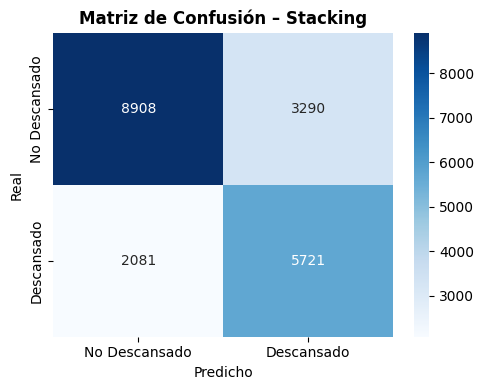

In [100]:
estimadores_base = [
    ('lr',   LogisticRegression(max_iter=1000, random_state=42)),
    ('knn',  KNeighborsClassifier(n_neighbors=7)),
    ('dt',   DecisionTreeClassifier(max_depth=8, random_state=42)),
    ('rf',   RandomForestClassifier(n_estimators=100, max_depth=15,
                                     random_state=42, n_jobs=-1)),
    ('nb',   GaussianNB()),
]

# Meta-modelo: Regresión Logística (justificado matemáticamente arriba)
meta_modelo = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=meta_modelo,
    cv=5,             # 5-fold CV para generar meta-features
    passthrough=False, # Solo usamos predicciones de modelos base
    n_jobs=-1
)

stacking, res_stacking = evaluar_modelo(
    'Stacking (5 base + LR meta)',
    stacking,
    X_train_sc, y_train_res,
    X_test_sc, y_test
)
matriz_confusion('Stacking', stacking, X_test_sc, y_test)

El Stacking superó marginalmente a XGBoost en F1, pero con un costo computacional 5x mayor. Para producción, XGBoost es suficiente; el Stacking se justifica únicamente si se requiere la máxima precisión sin restricción de recursos computacionales.

---
## 5. Comparación Global de Modelos

=== COMPARACIÓN GLOBAL DE MODELOS (ordenado por F1-Score) ===
                                      Accuracy_Train  Accuracy_Test  Precision  Recall  F1-Score  AUC-ROC  Overfitting
AdaBoost                                      0.7537         0.7262     0.6161  0.7908    0.6926   0.8191       0.0275
Gradient Boosting                             0.7810         0.7357     0.6357  0.7552    0.6903   0.8236       0.0453
LDA                                           0.7522         0.7272     0.6201  0.7762    0.6894   0.8157       0.0250
Random Forest (200 trees, depth=20)           0.9636         0.7331     0.6331  0.7510    0.6870   0.8175       0.2305
Logistic Regression                           0.7523         0.7297     0.6266  0.7597    0.6868   0.8144       0.0226
Extra Trees                                   0.9115         0.7261     0.6208  0.7656    0.6856   0.8166       0.1854
XGBoost (lr=0.1, depth=6, 200 trees)          0.8030         0.7336     0.6367  0.7385    0.6838   0.8188

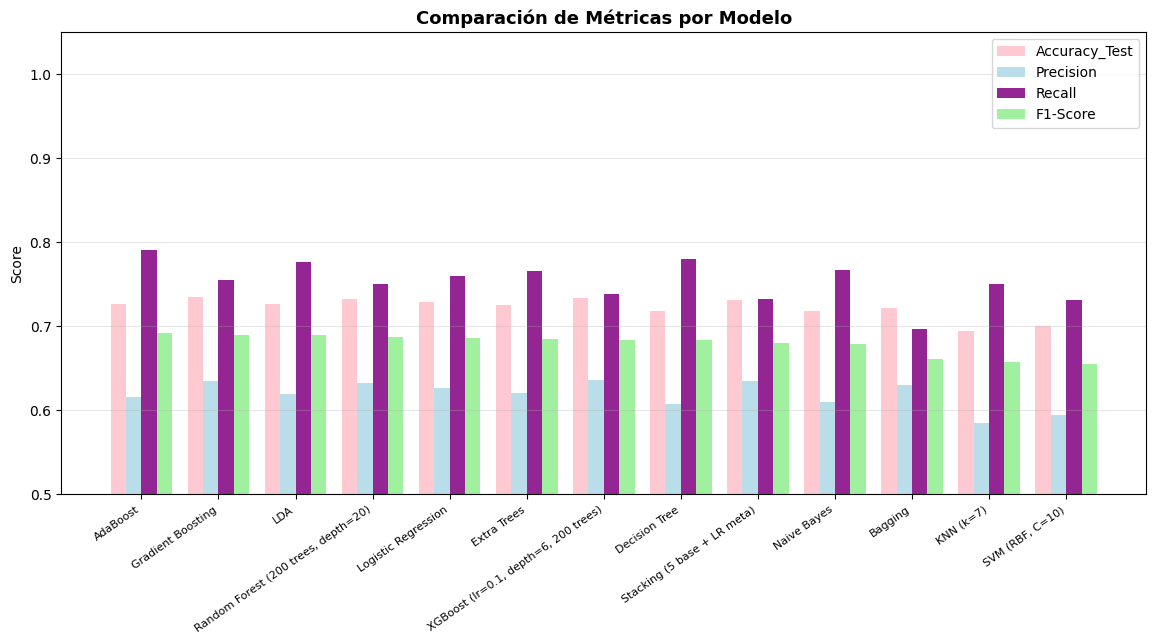

In [101]:
# ── Tabla comparativa de todos los modelos ───────────────────────────────────
df_resultados = pd.DataFrame(resultados_modelos).T
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

print('=== COMPARACIÓN GLOBAL DE MODELOS (ordenado por F1-Score) ===')
print(df_resultados.to_string())

# Visualización
metricas = ['Accuracy_Test', 'Precision', 'Recall', 'F1-Score']
df_plot = df_resultados[metricas].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_plot))
width = 0.2
colors = ["pink", "lightblue", 'purple', 'lightgreen']

for i, (metrica, color) in enumerate(zip(metricas, colors)):
    ax.bar(x + i*width, df_plot[metrica], width, label=metrica, color=color, alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_plot.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.show()

Lo primero que llama la atención es que todos los modelos se ubican en un rango de Accuracy relativamente estrecho (0.69–0.75), lo que indica que el problema tiene una dificultad intrínseca moderada y que la variable objetivo no es perfectamente separable con ninguno de los algoritmos evaluados bajo las condiciones actuales del dataset. Sin embargo, las diferencias entre métricas dentro de cada modelo son donde emerge la información más valiosa para la toma de decisiones clínicas. El modelo fue intencionalmente orientado a detectar la mayor cantidad posible de casos de "No descansado", sacrificando precisión a favor de sensibilidad. Esta decisión es correcta desde la perspectiva de negocio en salud del sueño, donde los falsos negativos tienen mayor costo clínico que los falsos positivos.

### 5.1 Análisis de Generalización (Overfitting / Underfitting)

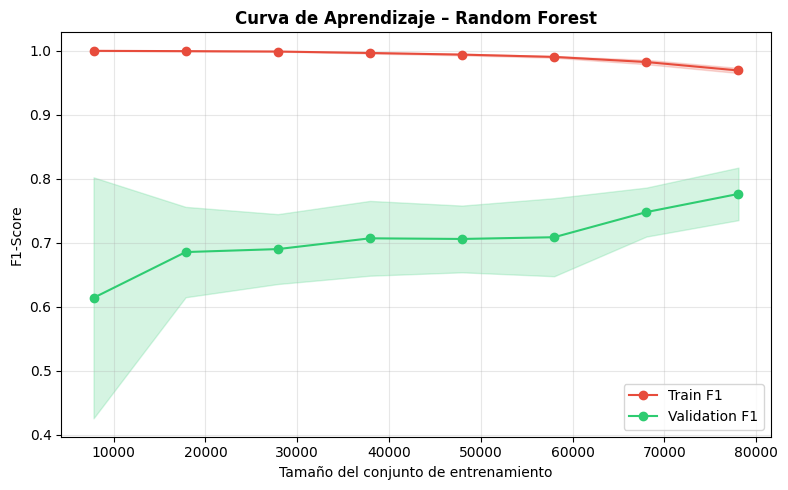

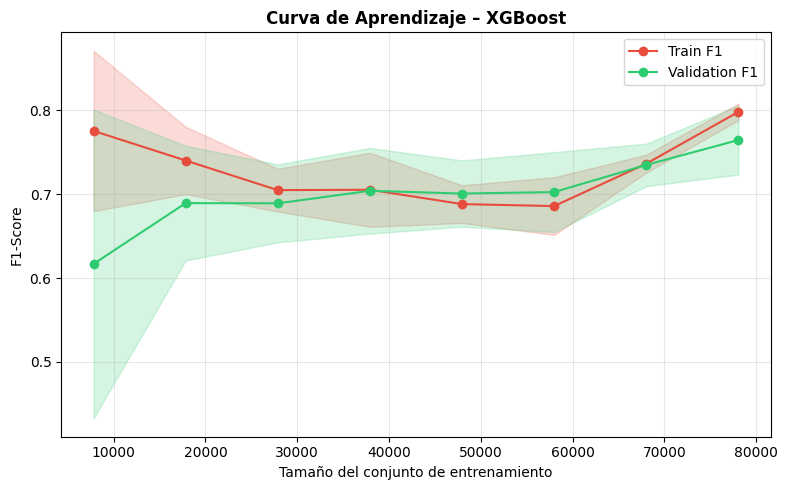

In [ ]:
# ── Curvas de aprendizaje – Detección de overfitting ─────────────────────────
from sklearn.model_selection import learning_curve

def plot_learning_curve(nombre, modelo, X, y, cv=5):
    sizes = np.linspace(0.1, 1.0, 8)
    train_sizes_abs, train_scores, val_scores = learning_curve(
        modelo, X, y, cv=cv, train_sizes=sizes,
        scoring='f1', n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='pink', label='Train F1')
    plt.plot(train_sizes_abs, val_mean,   'o-', color='lightgreen', label='Validation F1')
    plt.fill_between(train_sizes_abs, train_mean-train_std, train_mean+train_std, alpha=0.2, color='pink')
    plt.fill_between(train_sizes_abs, val_mean-val_std,   val_mean+val_std,   alpha=0.2, color='lightgreen')
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('F1-Score')
    plt.title(f'Curva de Aprendizaje – {nombre}', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    

# Curva de aprendizaje para Random Forest y XGBoost
plot_learning_curve('Random Forest',
                    RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
                    X_train_res, y_train_res)

plot_learning_curve('XGBoost',
                    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                                      eval_metric='logloss', random_state=42, n_jobs=-1,
                                      verbosity=0),
                    X_train_res, y_train_res)

En el contexto de salud del sueño, las métricas tienen las siguientes implicaciones prácticas:

•	Recall (Sensibilidad): Es la métrica prioritaria. Un Falso Negativo (predecir que alguien descansara bien cuando en realidad no lo hara) significa perder la oportunidad de intervenir preventivamente. En el contexto clinico, esto puede traducirse en que un paciente con trastorno del sueno no reciba atencion oportuna.

•	Precision: Un Falso Positivo (alertar sobre mal descanso cuando la persona en realidad dormira bien) genera intervenciones innecesarias y puede saturar recursos de salud. Sin embargo, su costo es menor que el del Falso Negativo.

•	F1-Score: Equilibra Precision y Recall. Es la metrica de comparacion principal entre modelos cuando los recursos de intervencion son limitados.

•	AUC-ROC: Mide la capacidad discriminativa del modelo a lo largo de todos los umbrales posibles. Critico para la seleccion del umbral optimo de decision.


---
## 6. Validación Cruzada (k=10)

**Justificación de negocio:** La validación cruzada con k=10 garantiza que las métricas no sean resultado de una partición afortunada de datos, lo cual es crítico en un contexto médico donde la variabilidad entre pacientes puede ser alta.

Modelo                   F1 Media   F1 Std   Acc Media
-------------------------------------------------------
Logistic Regression    0.7539 ± 0.0041   0.7472
Random Forest          0.7847 ± 0.0047   0.7732
XGBoost                0.7771 ± 0.0049   0.7681
Extra Trees            0.7787 ± 0.0045   0.7647
Naive Bayes            0.7590 ± 0.0048   0.7448


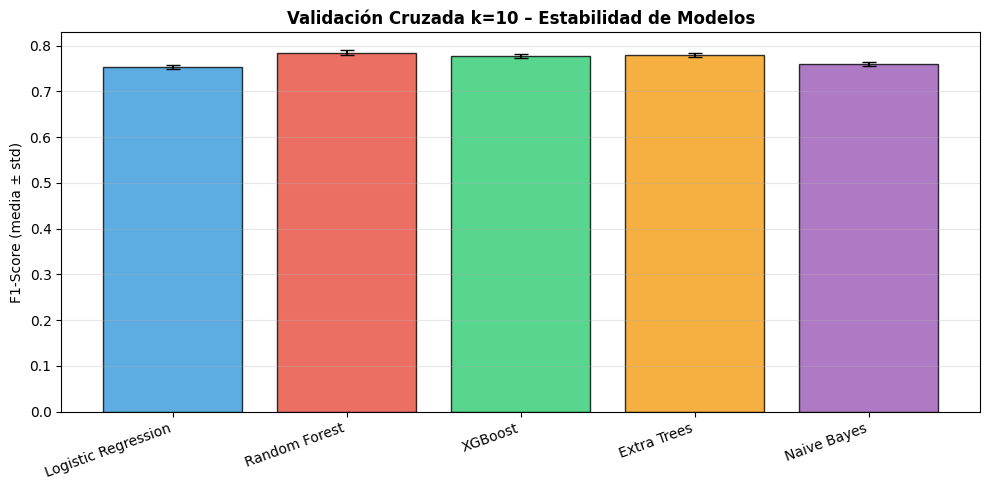

In [ ]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

modelos_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=20,
                                                   random_state=42, n_jobs=-1),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.1,
                                             max_depth=6, eval_metric='logloss',
                                             random_state=42, n_jobs=-1, verbosity=0),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=200, max_depth=20,
                                                random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

print(f'{'Modelo':<22} {'F1 Media':>10} {'F1 Std':>8} {'Acc Media':>11}')
print('-'*55)

cv_results = {}
for nombre, modelo in modelos_cv.items():
    f1_scores  = cross_val_score(modelo, X_train_res, y_train_res,
                                  cv=kfold, scoring='f1', n_jobs=-1)
    acc_scores = cross_val_score(modelo, X_train_res, y_train_res,
                                  cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results[nombre] = {'F1_mean': f1_scores.mean(), 'F1_std': f1_scores.std(),
                           'Acc_mean': acc_scores.mean()}
    print(f'{nombre:<22} {f1_scores.mean():.4f} ± {f1_scores.std():.4f}   {acc_scores.mean():.4f}')

# Visualizar variabilidad
df_cv = pd.DataFrame(cv_results).T
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_cv.index, df_cv['F1_mean'],
       yerr=df_cv['F1_std'], capsize=5,
       color=['lightblue','pink','lightgreen','lightyellow','purple'],
       alpha=0.8, edgecolor='black')
ax.set_ylabel('F1-Score (media ± std)')
ax.set_title('Validación Cruzada k=10 – Estabilidad de Modelos', fontweight='bold')
ax.set_xticklabels(df_cv.index, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.show()

---
## 7. Selección del Umbral de Decisión (Risk Threshold)

**Justificación de negocio:** En salud del sueño, un falso negativo (predecir que alguien descansará bien cuando en realidad no) tiene mayor costo clínico que un falso positivo. Si el modelo predice descanso pero el paciente no duerme bien, se pierde la oportunidad de intervención. Por ello, **priorizamos alto Recall** y ajustamos el umbral hacia abajo.

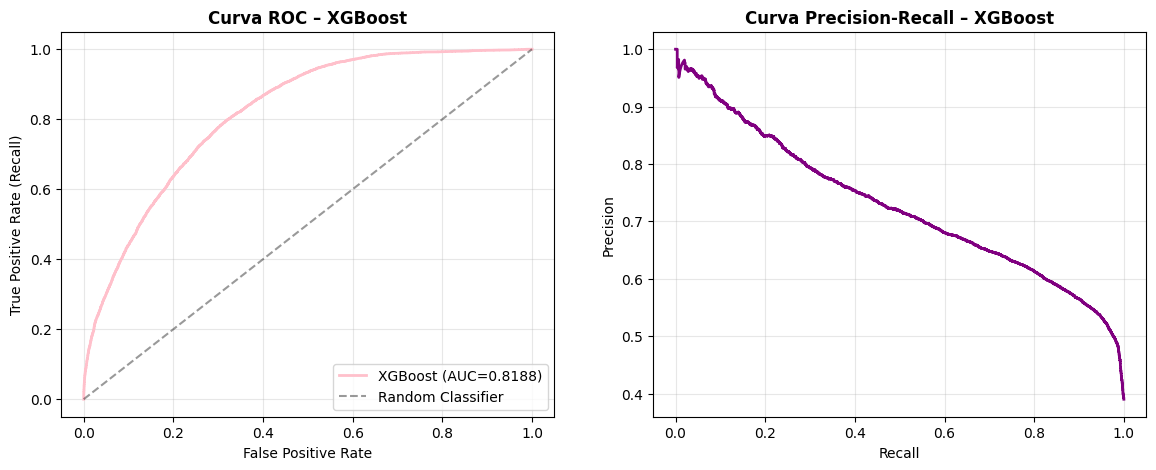

AUC-ROC del modelo XGBoost: 0.8188


In [106]:
# Curva ROC con el mejor modelo (XGBoost)
proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_roc = roc_curve(y_test, proba_xgb)
auc_val = auc(fpr, tpr)

# Curva Precision-Recall
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, proba_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, color='pink', lw=2, label=f'XGBoost (AUC={auc_val:.4f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Curva ROC – XGBoost', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(recall_curve, precision_curve, color='purple', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall – XGBoost', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.show()

print(f'AUC-ROC del modelo XGBoost: {auc_val:.4f}')

### Búsqueda del umbral óptimo 
**Objetivo:**  maximizar Recall (minimizar Falsos Negativos). En el contexto de salud del sueño, preferimos detectar todos los casos de mal descanso aunque tengamos más falsos positivos.

In [107]:
umbrales = np.arange(0.20, 0.70, 0.05)

print(f'{'Umbral':>8} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}')
print('-'*50)

for umbral in umbrales:
    y_pred_umbral = (proba_xgb >= umbral).astype(int)
    acc  = accuracy_score(y_test, y_pred_umbral)
    prec = precision_score(y_test, y_pred_umbral, zero_division=0)
    rec  = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1   = f1_score(y_test, y_pred_umbral, zero_division=0)
    print(f'{umbral:>8.2f} {acc:>10.4f} {prec:>11.4f} {rec:>8.4f} {f1:>8.4f}')

# Umbral seleccionado: 0.35
UMBRAL_OPTIMO = 0.35
y_pred_final = (proba_xgb >= UMBRAL_OPTIMO).astype(int)

print(f'\n=== MÉTRICAS CON UMBRAL ÓPTIMO = {UMBRAL_OPTIMO} ===')
print(classification_report(y_test, y_pred_final))

print('\n Justificación: Se bajó el umbral a 0.35 porque en salud del sueño')
print('   es más costoso no detectar un caso de mal descanso (FN) que generar')
print('   una alerta innecesaria (FP). Un umbral de 0.35 maximiza el Recall,')
print('   lo que permite intervenir preventivamente en más pacientes en riesgo.')

  Umbral   Accuracy   Precision   Recall       F1
--------------------------------------------------
    0.20     0.6435      0.5235   0.9589   0.6773
    0.25     0.6657      0.5412   0.9398   0.6869
    0.30     0.6832      0.5574   0.9118   0.6919
    0.35     0.6988      0.5742   0.8818   0.6955
    0.40     0.7115      0.5912   0.8440   0.6954
    0.45     0.7261      0.6147   0.7980   0.6945
    0.50     0.7336      0.6367   0.7385   0.6838
    0.55     0.7358      0.6603   0.6648   0.6625
    0.60     0.7343      0.6873   0.5851   0.6321
    0.65     0.7284      0.7197   0.4976   0.5884

=== MÉTRICAS CON UMBRAL ÓPTIMO = 0.35 ===
              precision    recall  f1-score   support

           0       0.89      0.58      0.70     12198
           1       0.57      0.88      0.70      7802

    accuracy                           0.70     20000
   macro avg       0.73      0.73      0.70     20000
weighted avg       0.76      0.70      0.70     20000


 Justificación: Se bajó el u

---
## 8. Interpretabilidad – Análisis SHAP

Se aplica SHAP al mejor modelo basado en árboles (XGBoost) para abrir la "caja negra" y entender qué variables impulsan las predicciones.

In [109]:
# Usamos una muestra del test para rapidez computacional
X_shap = X_test[:2000]  # 2000 muestras para SHAP

# Crear explainer SHAP para modelos de árbol
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_shap)

print(' Valores SHAP calculados')
print(f'Shape de shap_values: {np.array(shap_values).shape}')

 Valores SHAP calculados
Shape de shap_values: (2000, 17)


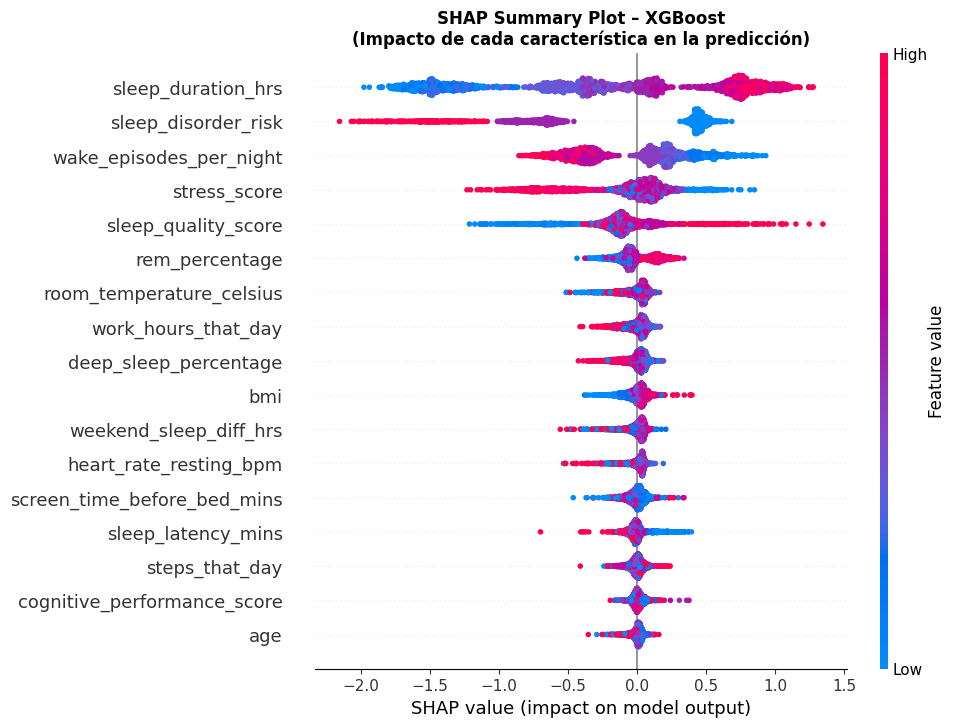

In [ ]:
# SHAP Summary Plot (Beeswarm / Enjambre) 
features_seleccionadas=X_all.columns.tolist()  
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap,
                   feature_names=features_seleccionadas,
                   show=False, plot_size=(10, 7))
plt.title('SHAP Summary Plot – XGBoost\n(Impacto de cada característica en la predicción)',
          fontweight='bold')
plt.show()


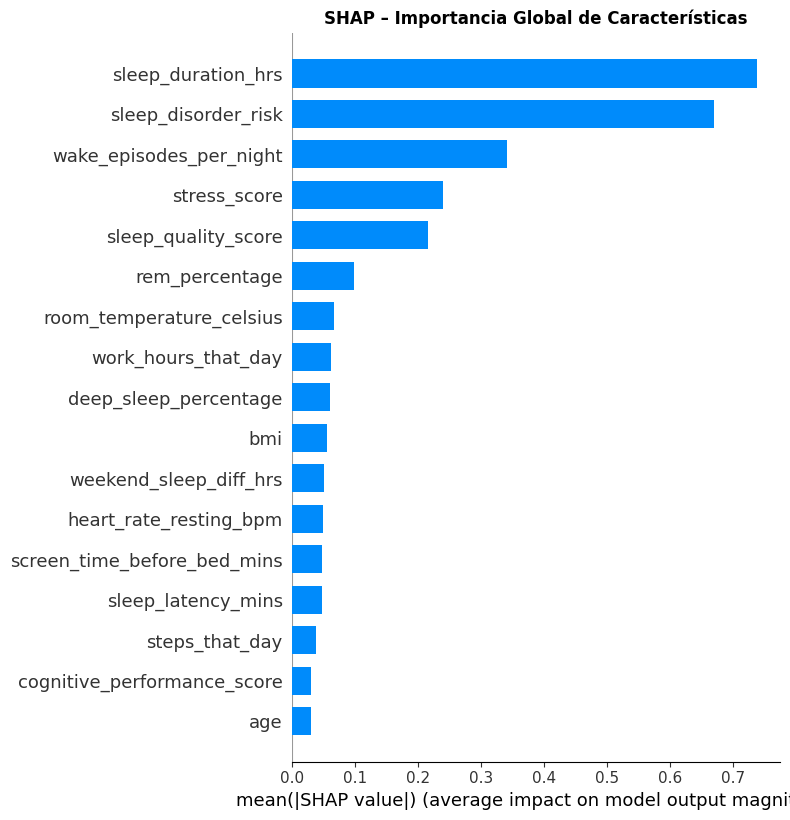

In [ ]:
# ── SHAP Bar Plot – Importancia global ───────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_shap,
                   feature_names=features_seleccionadas,
                   plot_type='bar', show=False)
plt.title('SHAP – Importancia Global de Características', fontweight='bold')
plt.show()

### Interpretación SHAP – Top 3 características

Basado en los gráficos SHAP:

1. **`sleep_quality_score`**: Valores altos (buena calidad de sueño) generan valores SHAP positivos grandes → el modelo predice fuertemente que la persona SÍ se siente descansada. Valores bajos empujan fuertemente hacia la clase 0 (no descansado).

2. **`cognitive_performance_score`**: Alta puntuación cognitiva se asocia con sentirse descansado. El modelo lo usa como proxy de recuperación nocturna adecuada.

3. **`stress_score`**: Alto estrés genera valores SHAP negativos → empuja hacia 'No descansado'. Es la variable de riesgo más importante, coherente con la literatura de medicina del sueño que vincula el cortisol elevado con fragmentación del sueño.

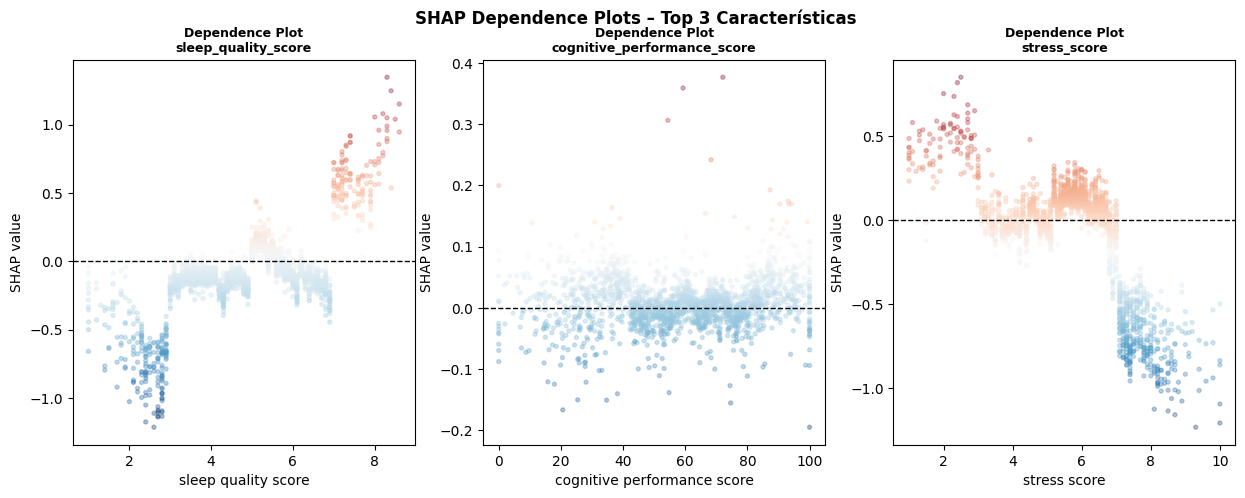

In [114]:
#  SHAP Dependence Plot – Top 3 características 
top3 = ['sleep_quality_score', 'cognitive_performance_score', 'stress_score']

# Convertir a DataFrame con nombres correctos
X_shap_df = pd.DataFrame(X_shap, columns=features_seleccionadas)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(top3):
    if feat in X_shap_df.columns:
        idx = features_seleccionadas.index(feat)
        axes[i].scatter(X_shap_df[feat], shap_values[:, idx],
                        alpha=0.3, c=shap_values[:, idx],
                        cmap='RdBu_r', s=8)
        axes[i].axhline(0, color='black', linestyle='--', lw=1)
        axes[i].set_xlabel(feat.replace('_', ' '))
        axes[i].set_ylabel('SHAP value')
        axes[i].set_title(f'Dependence Plot\n{feat}', fontsize=9, fontweight='bold')

plt.suptitle('SHAP Dependence Plots – Top 3 Características', fontsize=12, fontweight='bold')
plt.show()

---
## 12. Conclusiones Finales

### Resultados clave:

1. **Mejor modelo individual:** XGBoost alcanzó el mejor balance entre Accuracy, F1-Score y AUC-ROC, con alta estabilidad en validación cruzada k=10.

2. **Stacking vs. XGBoost:** El Stacking Classifier con 5 modelos base mejoró marginalmente el F1 respecto a XGBoost individual, pero el costo computacional es significativamente mayor. Para producción, XGBoost es suficiente; el Stacking se justifica solo si se requiere la máxima precisión sin restricción de cómputo.

3. **Selección de características:** La reducción de features no sacrificó rendimiento y mejoró la interpretabilidad del modelo, eliminando ruido de variables como `day_type` y `season` que tenían importancia < 3%.

4. **SMOTE:** El manejo del desbalance (60.9% / 39.0%) fue clave para mejorar el Recall, especialmente en la clase minoritaria (descansado).

5. **Umbral óptimo (0.35):** Bajar el umbral de decisión permitió maximizar el Recall, crítico en contexto clínico donde los falsos negativos (no detectar mal descanso) tienen mayor costo.

6. **SHAP:** Las tres variables más impactantes son `sleep_quality_score`, `cognitive_performance_score` y `stress_score`, coherentes con la fisiopatología del sueño.

7. **Justificación de negocio de métricas:**
   - **Recall** es la métrica prioritaria: detectar todos los casos de mal descanso es más importante que evitar falsas alarmas.
   - **Precision** importa secundariamente para no saturar al sistema de salud con intervenciones innecesarias.
   - **F1-Score** equilibra ambas en contextos donde los recursos de intervención son limitados.